Лабораторная работа №1

In [108]:
import matplotlib.pyplot as plt
import numpy as np
import random
from os.path  import join
import struct
from array import array
from pathlib import Path
import kagglehub
import time

Загрузка датасета с https://www.kaggle.com/datasets/hojjatk/mnist-dataset/data

Пример загрузчика взят с https://www.kaggle.com/code/hojjatk/read-mnist-dataset

In [109]:
class MnistDataloader(object):
    def __init__(self, training_images_filepath,training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath

    def read_images_labels(self, images_filepath, labels_filepath):
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = array("B", file.read())

        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read())
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            images[i] = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])

        return images, labels

    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train),(x_test, y_test)

In [110]:

input_path = kagglehub.dataset_download("hojjatk/mnist-dataset")

training_images_filepath = join(input_path, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')

mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)
(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()

Визуализация данных

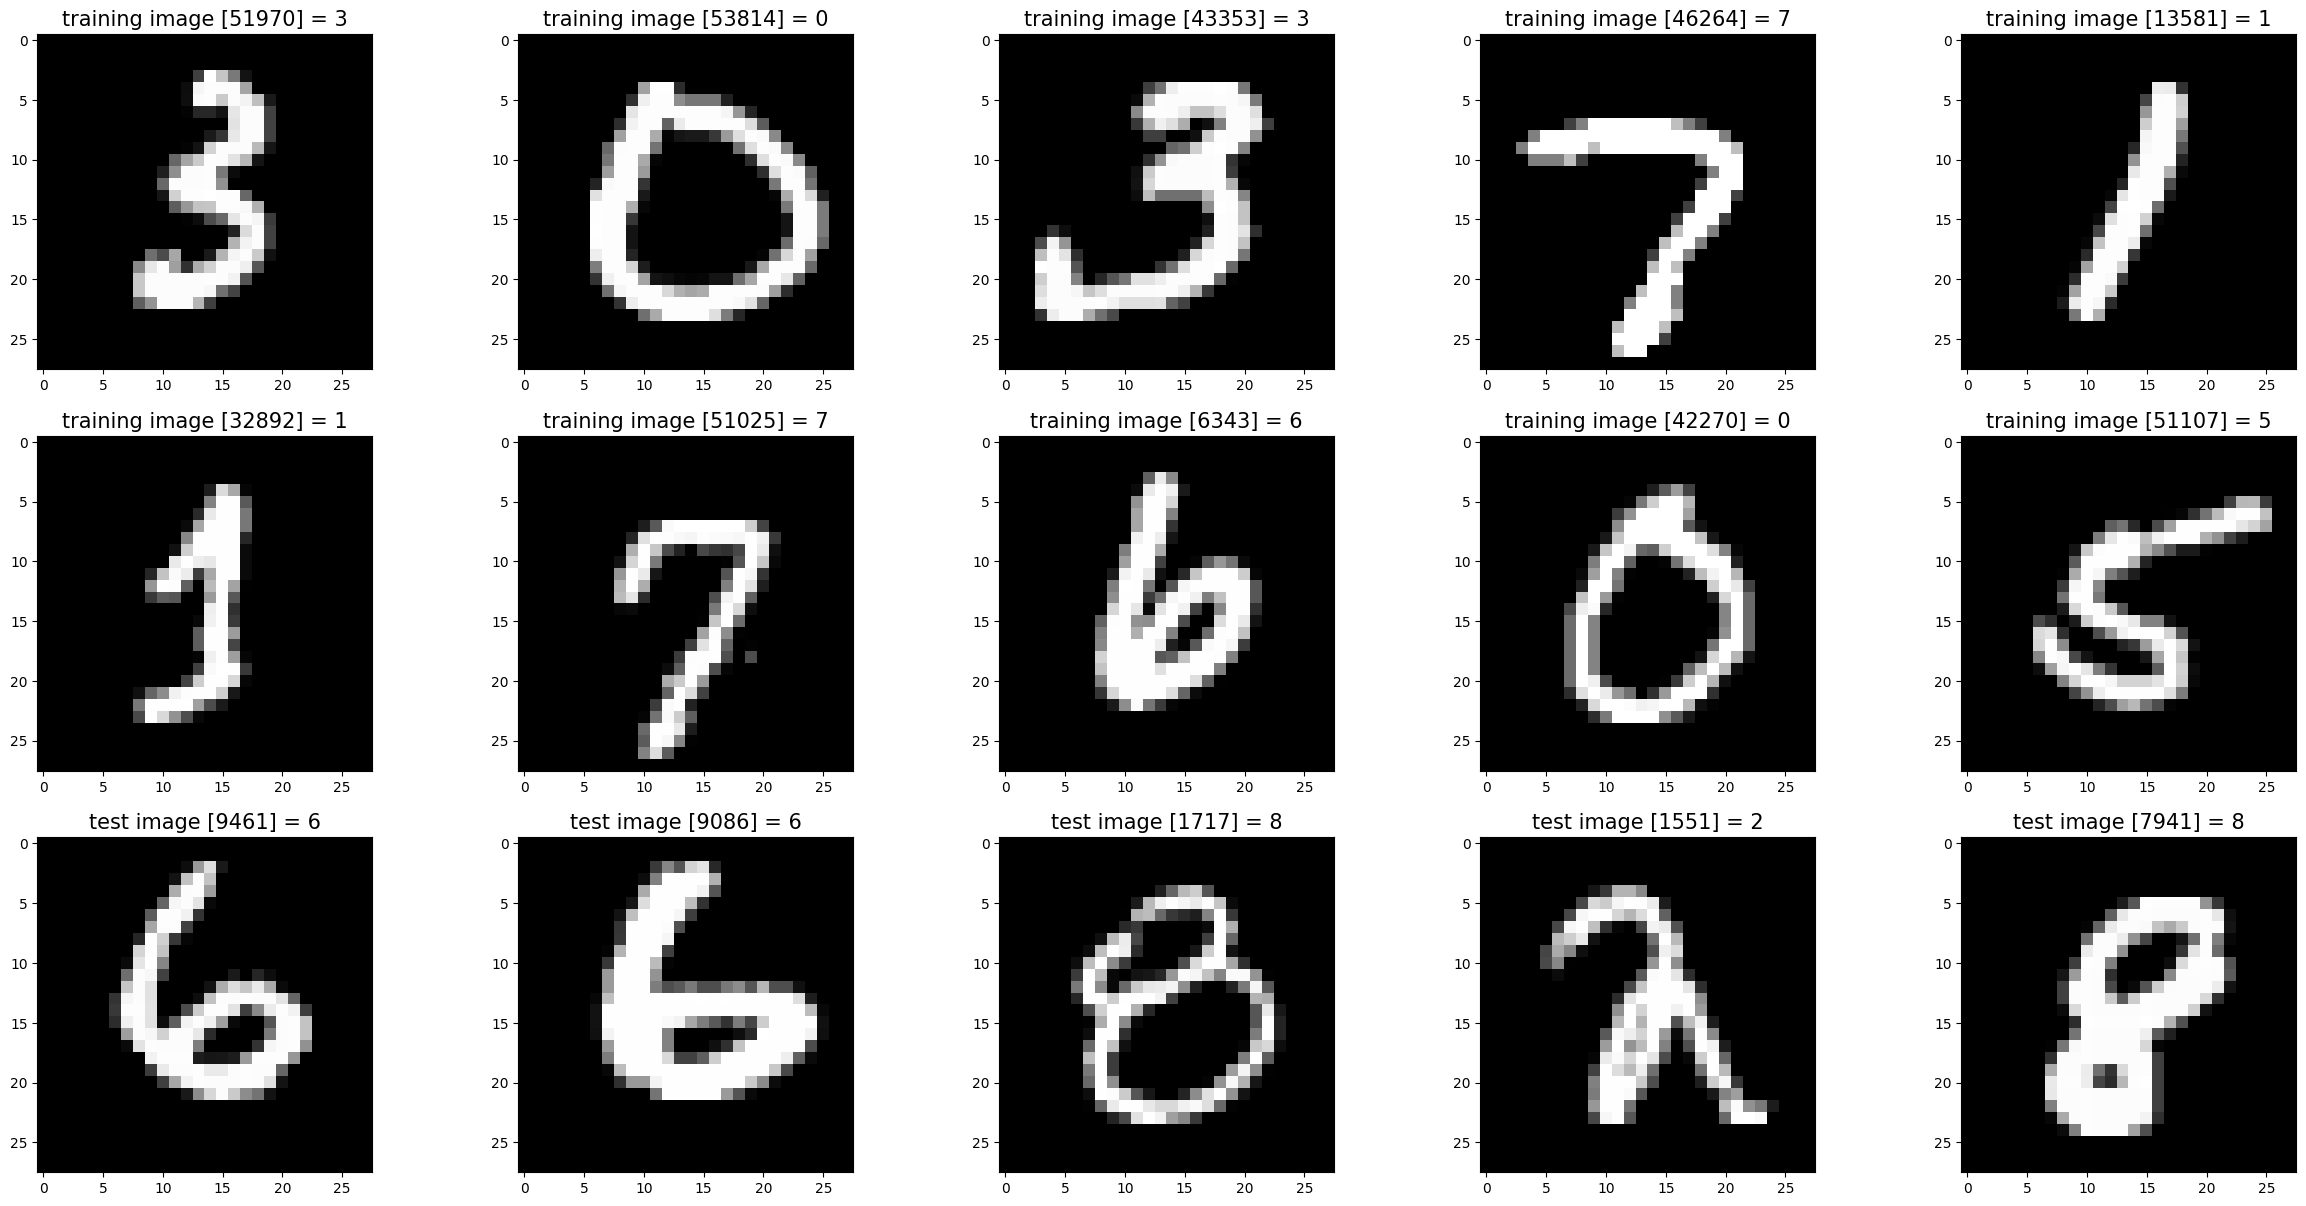

In [111]:
def show_images(images, title_texts):
    cols = 5
    rows = int(len(images)/cols) + 1
    plt.figure(figsize=(30,20))
    index = 1
    for image, title_text in zip(images, title_texts):
        plt.subplot(rows, cols, index)
        plt.imshow(image.reshape(28, 28), cmap=getattr(plt.cm, "gray", None))
        if (title_text != ''):
            plt.title(title_text, fontsize = 15)
        index += 1

images_2_show = []
titles_2_show = []
for i in range(0, 10):
    r = random.randint(1, 60000)
    images_2_show.append(x_train[r])
    titles_2_show.append('training image [' + str(r) + '] = ' + str(y_train[r]))

for i in range(0, 5):
    r = random.randint(1, 10000)
    images_2_show.append(x_test[r])
    titles_2_show.append('test image [' + str(r) + '] = ' + str(y_test[r]))

show_images(images_2_show, titles_2_show)

Нормирование данных. One hot encode для признака

In [112]:
def one_hot_encode(arr):
    classes = np.unique(arr)
    n_classes = len(classes)
    one_hot = np.zeros((arr.size, n_classes), dtype=np.float64)
    for index, value in enumerate(arr):
        class_index = np.where(classes == value)[0][0]
        one_hot[index, class_index] = 1.0
    return one_hot

X_train = np.array(x_train, dtype=np.float64) / 255.0
X_test = np.array(x_test, dtype=np.float64) / 255.0
y_train = one_hot_encode(np.array(y_train, dtype=int))
y_test = one_hot_encode(np.array(y_test, dtype=int))

print("Размер обучающей выборки : ", str(X_train.shape))
print("Целевой признак : ", str(y_train.shape))
print("Размер тестовой выборки : ", str(X_test.shape))
print("Целевой признак : ", str(y_test.shape))


Размер обучающей выборки :  (60000, 784)
Целевой признак :  (60000, 10)
Размер тестовой выборки :  (10000, 784)
Целевой признак :  (10000, 10)


Реализация нейросети

In [113]:
class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size, learning_rate):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.learning_rate = learning_rate

        self.W1 = np.random.randn(input_size, hidden_size) *  np.sqrt(2.0 / input_size)
        self.b1 = np.zeros((1, hidden_size))
        
        self.W2 = np.random.randn(hidden_size, output_size) *  np.sqrt(2.0 / hidden_size)
        self.b2 = np.zeros((1, output_size))

    def relu(self, Z):
        return np.maximum(0, Z)

    def relu_derivative(sefl, Z):
        return Z > 0

    def softmax(self, Z):
        expZ = np.exp(Z - np.max(Z, axis=1, keepdims=True))
        return expZ / expZ.sum(axis=1, keepdims=True)

    def compute_loss(self, y_true, y_pred):
        m = y_true.shape[0]
        return -np.sum(y_true * np.log(y_pred + 1e-9)) / m
    
    def forward_propagation(self, X):
        Z1 = X.dot(self.W1) + self.b1
        A1 = self.relu(Z1)
        Z2 = A1.dot(self.W2) + self.b2
        A2 = self.softmax(Z2)
        return Z1, A1, Z2, A2
    
    def backward_propagation(self, X, y_true, Z1, A1, Z2, A2):
        m = y_true.shape[0]
        dZ2 = A2 - y_true

        dW2 = (A1.T).dot(dZ2) / m

        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        dA1 = dZ2.dot(self.W2.T)

        dZ1 = dA1 * self.relu_derivative(Z1)

        dW1 = (X.T).dot(dZ1) / m

        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        return dW1, db1, dW2, db2
    
    def update_parameters(self, dW1, db1, dW2, db2):
        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1
        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2


In [114]:
def train_network(network : NeuralNetwork, X_train, y_train, X_test, y_test, 
                  epochs=20, batch_size=32):
    
    for epoch in range(epochs):
        start_time = time.time()
        
        permutation = np.random.permutation(X_train.shape[0])
        X_train_shuffled = X_train[permutation]
        y_train_shuffled = y_train[permutation]
        
        epoch_loss = 0
        
        for i in range(0, X_train.shape[0], batch_size):            
            X_batch = X_train_shuffled[i:i+batch_size]
            y_batch = y_train_shuffled[i:i+batch_size]
            
            
            Z1, A1, Z2, A2 = network.forward_propagation(X_batch)
            
            batch_loss = network.compute_loss(y_batch, A2)
            epoch_loss += batch_loss
            
            dW1, db1, dW2, db2 = network.backward_propagation(X_batch, y_batch, Z1, A1, Z2, A2)
            
            network.update_parameters(dW1, db1, dW2, db2)
        
        _, _, _, A2_train = network.forward_propagation(X_train)
        train_accuracy = np.mean(np.argmax(A2_train, axis=1) == np.argmax(y_train, axis=1))
        end_time = time.time()
        print(f"Epoch {epoch+1}: Elapsed {end_time - start_time:.2f} seconds, Train accuracy: {train_accuracy:.4f}, loss : {(epoch_loss / (X_train.shape[0] // batch_size)):.4f}")
    _, _, _, A2_test = network.forward_propagation(X_test)
    test_accuracy = np.mean(np.argmax(A2_test, axis=1) == np.argmax(y_test, axis=1))
    print(f"Test accuracy: {test_accuracy:.4f}")


In [115]:
INPUT_SIZE = 784
HIDDEN_SIZE = 300
OUTPUT_SIZE = 10
LEARNING_RATE = 0.1
BATCH_SIZE = 32
EPOCHS = 20

network = NeuralNetwork(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    output_size=OUTPUT_SIZE,
    learning_rate=LEARNING_RATE
)

train_network(
    network, 
    X_train, y_train, 
    X_test, y_test,
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE
)

Epoch 1: Elapsed 5.30 seconds, Train accuracy: 0.9583, loss : 0.2812
Epoch 2: Elapsed 5.23 seconds, Train accuracy: 0.9739, loss : 0.1297
Epoch 3: Elapsed 5.12 seconds, Train accuracy: 0.9786, loss : 0.0917
Epoch 4: Elapsed 5.24 seconds, Train accuracy: 0.9845, loss : 0.0710
Epoch 5: Elapsed 5.13 seconds, Train accuracy: 0.9864, loss : 0.0571
Epoch 6: Elapsed 5.20 seconds, Train accuracy: 0.9904, loss : 0.0471
Epoch 7: Elapsed 5.31 seconds, Train accuracy: 0.9908, loss : 0.0391
Epoch 8: Elapsed 5.12 seconds, Train accuracy: 0.9942, loss : 0.0330
Epoch 9: Elapsed 5.18 seconds, Train accuracy: 0.9957, loss : 0.0278
Epoch 10: Elapsed 5.17 seconds, Train accuracy: 0.9965, loss : 0.0234
Epoch 11: Elapsed 5.10 seconds, Train accuracy: 0.9970, loss : 0.0199
Epoch 12: Elapsed 5.11 seconds, Train accuracy: 0.9983, loss : 0.0169
Epoch 13: Elapsed 5.11 seconds, Train accuracy: 0.9988, loss : 0.0146
Epoch 14: Elapsed 5.22 seconds, Train accuracy: 0.9990, loss : 0.0123
Epoch 15: Elapsed 5.14 second

Итоги:
Выполнена реализация нейронной сети с предложенными параметрами.
Accuracy на тренировочной выборке составил более 99%, на тестовой более 98%